<a href="https://colab.research.google.com/github/Dhanshree010/pattern-recognition-practical/blob/main/practical_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
df = pd.read_csv("diabetes.csv")

In [2]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------
# Original Model
# --------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Original Accuracy:",
      accuracy_score(y_test, pred))

# --------------------
# PCA
# --------------------
pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model_pca = LogisticRegression(max_iter=1000)

model_pca.fit(X_train_pca, y_train)

pred_pca = model_pca.predict(X_test_pca)

print("PCA Accuracy:",
      accuracy_score(y_test, pred_pca))


Original Accuracy: 0.7532467532467533
PCA Accuracy: 0.7467532467532467


In [3]:
lda = LinearDiscriminantAnalysis(
    n_components=1
)

X_train_lda = lda.fit_transform(
    X_train,
    y_train
)

X_test_lda = lda.transform(
    X_test
)

model_lda = LogisticRegression(
    max_iter=1000
)

model_lda.fit(
    X_train_lda,
    y_train
)

pred_lda = model_lda.predict(
    X_test_lda
)

print("LDA Accuracy:",
      accuracy_score(
          y_test,
          pred_lda
      ))

print("\nClassification Report")
print(
classification_report(
    y_test,
    pred_lda
))

LDA Accuracy: 0.7597402597402597

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



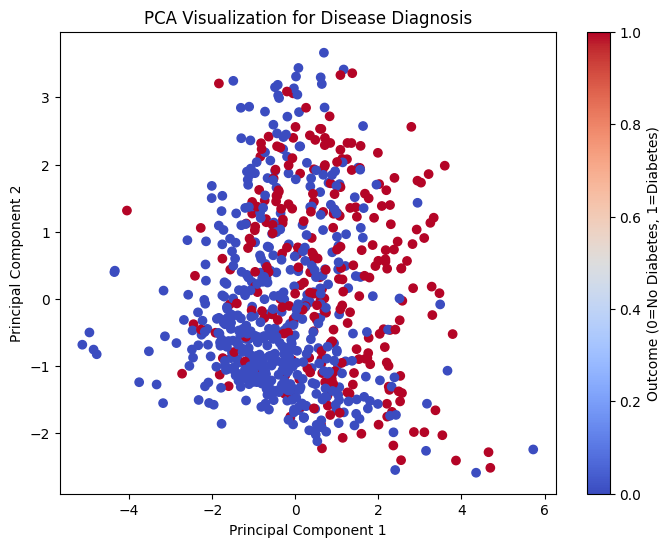

In [7]:

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap="coolwarm"
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization for Disease Diagnosis")
plt.colorbar(label="Outcome (0=No Diabetes, 1=Diabetes)")
plt.show()